In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson


In [2]:
mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [3]:
# Calculo del periodo de oscilación del inflatón en el potencial lphi4
def oscilation(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

# ----------------------------------------------------------------------

"""Dinámica"""

# Dinamica sin expansión del universo para el modelo lphi4
def pert(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Dinamica con expansión del universo para el modelo lphi4
def pert_exp(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + q * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

# Número de partículas producidas en el modo k
def number(k, q, phi, chik, chidot, a):
    omega_k = np.sqrt(k**2/a**2 + q * phi**2)
    nk = omega_k / 2 * ( (np.abs(chidot)/omega_k)**2 + np.abs(chik)**2 )
    return nk, omega_k

#-------------------------------------------------------------------------------------------------------------------------------------
"""Condiciones iniciales"""
def CI(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))#1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2) 

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]
    return y0

def CI_exp(k, q):
    # Background
    phi0 = 1
    phi_dot0 = phi0**2/np.sqrt(2)
    areh = 1
    a_dot0 = np.sqrt( (phi_dot0**2/2 + phi0**4/4) / 3 ) * areh

    # Perturbaciones
    Omega_chi = np.sqrt(k**2 + q * phi0**2)
    chi_k0 = 0 #1/(np.sqrt(2 * Omega_chi))
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi))) #np.sqrt(Omega_chi/2)

    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, a_dot0]
    return y0

In [4]:
"""Parámetros"""

# Narrow Resonance
qn = 0.5
kn = 0.8277856966198477

# Broad Resonance
qb = 5050
kb = 6.4686076615463275

# Condiciones iniciales
y0 = CI(kn, qn)
phi0, phi_dot0 = y0[0], y0[1]

# Tiempos
Tosc = oscilation(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)

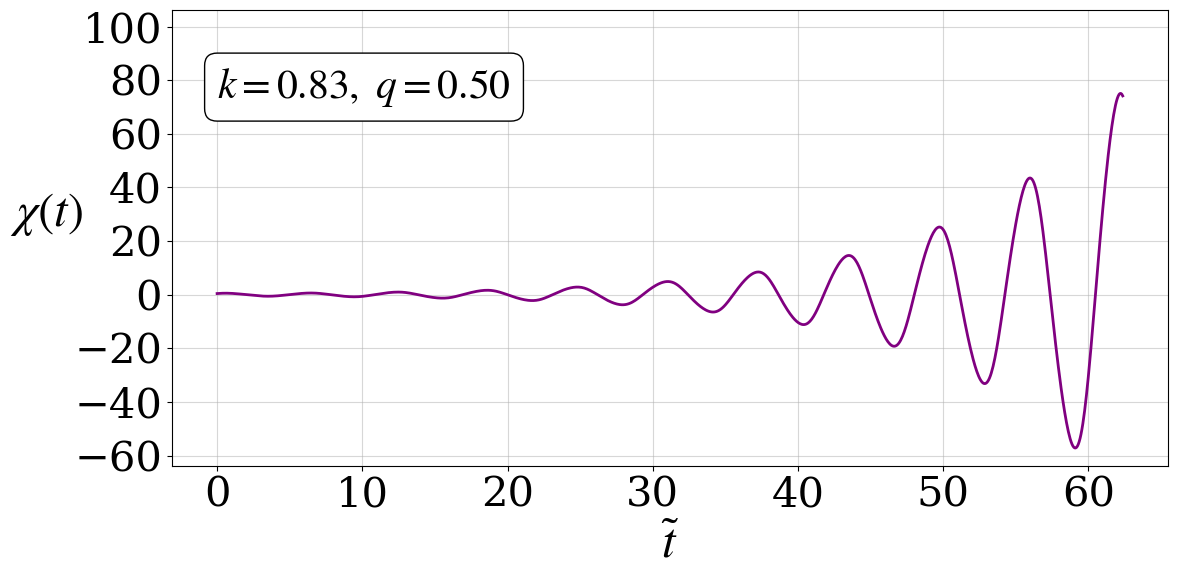

In [5]:
sol_narrow = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], t_span[-1], 1000), method='RK45', rtol=1e-6, args=(kn, qn))

plt.figure(figsize=(12, 6))
plt.plot(sol_narrow.t, sol_narrow.y[2], lw = 2, color = "purple")
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_narrow.t[0], y=ymax*0.9, s=rf'$k = {kn:.2f}, ~ q = {qn:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
plt.grid(alpha=0.5)
#plt.show()
plt.savefig("Narrow_Resonance_lphi4.pdf", format = "pdf")

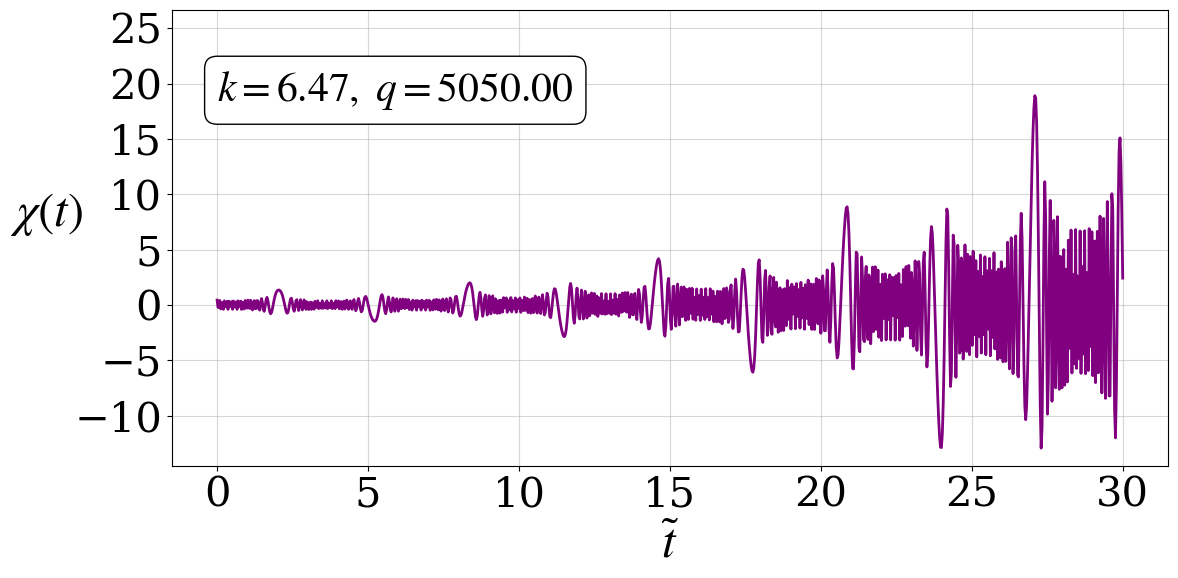

In [6]:
sol_broad = solve_ivp(pert, t_span, y0, t_eval=np.linspace(t_span[0], 30, 1000), method='RK45', rtol=1e-6, args=(kb, qb))

plt.figure(figsize=(12, 6))
plt.plot(sol_broad.t, sol_broad.y[2], lw = 2, color = "purple")
plt.grid(alpha=0.5)
ymin, ymax = plt.gca().get_ylim()
plt.ylim(ymin, ymax*1.3)
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$\chi(t)$', labelpad=20, rotation='horizontal', fontsize = 35)
plt.text(x=sol_broad.t[0], y=ymax*0.9, s=rf'$k = {kb:.2f}, ~ q = {qb:.2f}$', fontsize=30, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.tight_layout()
#plt.show()
plt.savefig("Broad_Resonance_lphi4.pdf", format = "pdf")

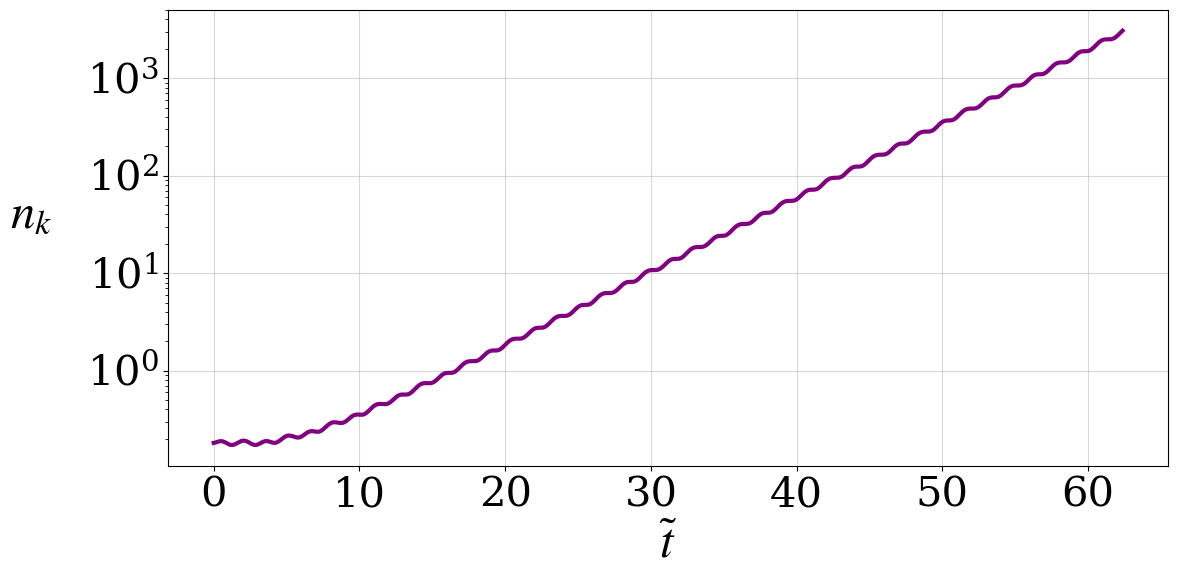

In [7]:
nk, omegak = number(kn, qn, sol_narrow.y[0], sol_narrow.y[2], sol_narrow.y[3], 1)
t = sol_narrow.t

plt.figure(figsize=(12, 6))
plt.semilogy(t, nk, lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Narrow_Resonance_lphi4.pdf", format = "pdf")

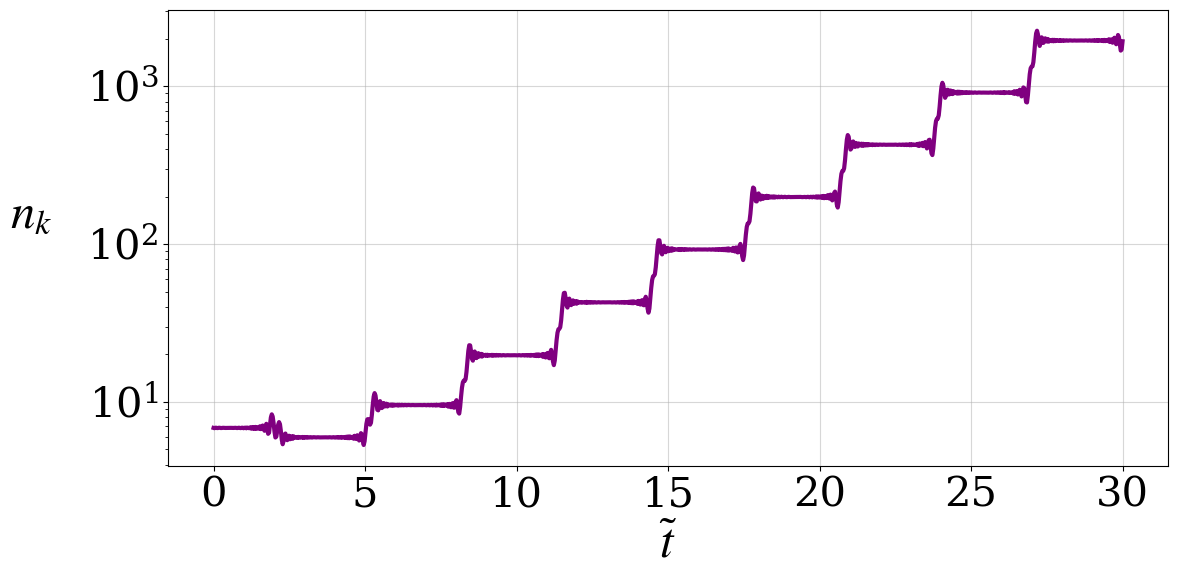

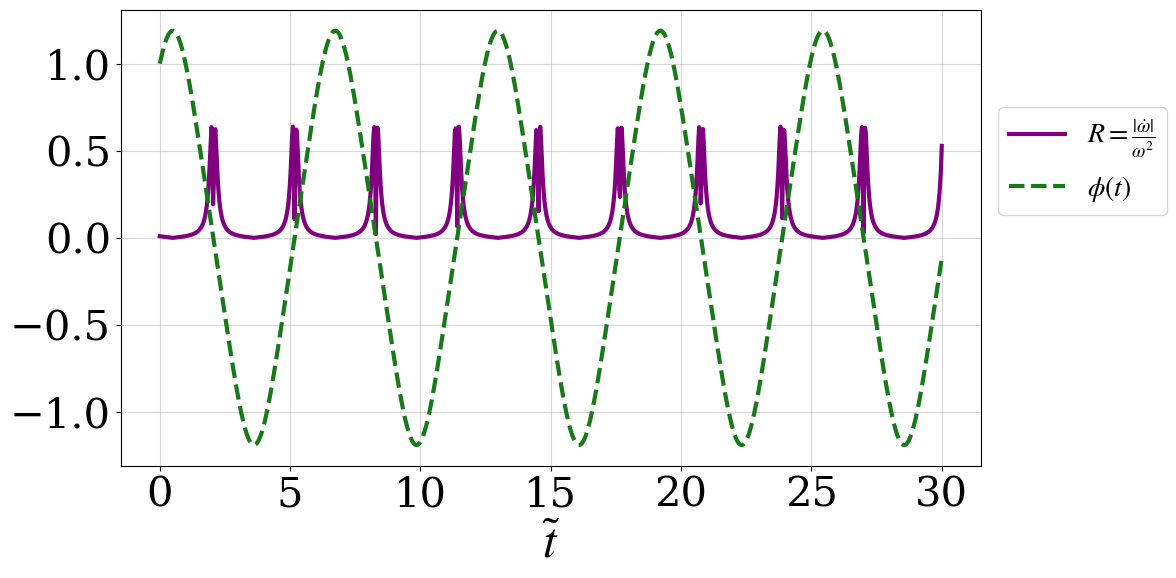

In [9]:
nk, omegak = number(kb, qb, sol_broad.y[0], sol_broad.y[2], sol_broad.y[3], 1)
t = sol_broad.t

plt.figure(figsize=(12, 6))
plt.semilogy(t, nk, lw = 3, color = "purple")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.ylabel(r'$n_k$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("nk_Broad_Resonance_lphi4.pdf", format = "pdf")


omegak_prime = np.gradient(omegak, t)
adiabaticity = np.abs(omegak_prime) / omegak**2
plt.figure(figsize=(12, 6))
plt.plot(t, adiabaticity, lw = 3, color = "purple", label = r'$R = \frac{|\dot{\omega}|}{\omega^2}$')
plt.plot(t, sol_broad.y[0], lw = 3, color = "#177917", label = r'$\phi(t)$', ls = "--")
plt.xlabel(r'$\tilde{t}$', fontsize = 35)
plt.legend(fontsize = 20, loc = (1.02,0.55))
#plt.ylabel(r'$R$', fontsize = 35, rotation='horizontal', labelpad=40)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
#plt.yscale('log')
plt.grid(alpha=0.5)
plt.tight_layout()
#plt.show()
plt.savefig("Adiabaticity_lphi4.pdf", format = "pdf")